# Lab 4: Interacting with Foundation Models

**Part 3 — From Transformers to Large Language Models**

---

**Objectives:**
- Load and compare open-source LLMs (SmolLM2, Qwen2.5, Phi-3-mini) using Hugging Face Transformers
- Generate text with different decoding strategies (greedy, sampling, beam search)
- Analyze the impact of temperature, top-k, and top-p sampling parameters
- Visualize token probabilities and the generation process
- Compare tokenizers across different model families
- Test zero-shot and few-shot in-context learning capabilities

**Tools:** Python, Hugging Face Transformers, Matplotlib, Pandas

> **Note:** This lab uses small open-source models that can run on CPU or a single GPU. For production use, larger models require more compute.

## 0. Environment Setup

In [1]:
# Install dependencies (uncomment on Google Colab)
!pip install transformers accelerate torch sentencepiece protobuf
!pip install matplotlib seaborn pandas numpy

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.10.0


---

# PART 1 — Loading and Comparing Foundation Models

---

We will work with three small but capable open-source models from different families:

| Model | Family | Parameters | Architecture | Tokenizer |
|-------|--------|-----------|--------------|-----------|
| **SmolLM2-135M-Instruct** | SmolLM (Hugging Face) | 135M | Decoder-only | BPE |
| **Qwen2.5-0.5B-Instruct** | Qwen (Alibaba) | 0.5B | Decoder-only | BPE (tiktoken-based) |
| **SmolLM2-360M-Instruct** | SmolLM (Hugging Face) | 360M | Decoder-only | BPE |

> These models are small enough to run on CPU but demonstrate all the core concepts of larger LLMs (GPT-4, Llama 3, Mistral, etc.).

## Step 1: Load Models and Tokenizers

We define a dictionary of models and load them with their tokenizers. Each model uses `AutoModelForCausalLM` — the standard class for **autoregressive** (decoder-only) language models.

In [3]:
MODEL_CONFIGS = {
    "SmolLM2-135M": {
        "name": "HuggingFaceTB/SmolLM2-135M-Instruct",
        "description": "SmolLM2 135M — Hugging Face's compact instruct model",
    },
    "Qwen2.5-0.5B": {
        "name": "Qwen/Qwen2.5-0.5B-Instruct",
        "description": "Qwen 2.5 0.5B — Alibaba's small instruct model",
    },
    "SmolLM2-360M": {
        "name": "HuggingFaceTB/SmolLM2-360M-Instruct",
        "description": "SmolLM2 360M — Hugging Face's mid-size instruct model",
    },
}

# Load all models and tokenizers
models = {}
tokenizers = {}

for key, config in MODEL_CONFIGS.items():
    print(f"Loading {key}: {config['name']}...")
    tokenizers[key] = AutoTokenizer.from_pretrained(config["name"], trust_remote_code=True)
    models[key] = AutoModelForCausalLM.from_pretrained(
        config["name"],
        torch_dtype=torch.float32,  # CPU-friendly
        trust_remote_code=True,
    ).to(device)
    models[key].eval()

    # Count parameters
    n_params = sum(p.numel() for p in models[key].parameters())
    print(f"  ✓ Loaded — {n_params / 1e6:.1f}M parameters")

print("\nAll models loaded!")

Loading SmolLM2-135M: HuggingFaceTB/SmolLM2-135M-Instruct...
  ✓ Loaded — 134.5M parameters
Loading Qwen2.5-0.5B: Qwen/Qwen2.5-0.5B-Instruct...


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


  ✓ Loaded — 494.0M parameters
Loading SmolLM2-360M: HuggingFaceTB/SmolLM2-360M-Instruct...
  ✓ Loaded — 361.8M parameters

All models loaded!


## Step 2: Model Architecture Comparison

Let's compare the architectures of our three models. All are **decoder-only Transformers** but differ in:
- Number of layers (depth)
- Hidden dimension (width)
- Number of attention heads
- Vocabulary size
- Context window length

In [4]:
arch_data = []
for key in MODEL_CONFIGS:
    config = models[key].config
    n_params = sum(p.numel() for p in models[key].parameters())
    arch_data.append({
        "Model": key,
        "Parameters (M)": f"{n_params / 1e6:.1f}",
        "Layers": getattr(config, "num_hidden_layers", "N/A"),
        "Hidden Dim": getattr(config, "hidden_size", "N/A"),
        "Attention Heads": getattr(config, "num_attention_heads", "N/A"),
        "KV Heads": getattr(config, "num_key_value_heads", "N/A"),
        "Vocab Size": getattr(config, "vocab_size", "N/A"),
        "Max Context": getattr(config, "max_position_embeddings", "N/A"),
    })

df_arch = pd.DataFrame(arch_data)
df_arch.style.set_caption("Model Architecture Comparison")

,Model,Parameters (M),Layers,Hidden Dim,Attention Heads,KV Heads,Vocab Size,Max Context
0,SmolLM2-135M,134.5,30,576,9,3,49152,8192
1,Qwen2.5-0.5B,494.0,24,896,14,2,151936,32768
2,SmolLM2-360M,361.8,32,960,15,5,49152,8192


### Key Observations

- **Grouped-Query Attention (GQA):** When `KV Heads < Attention Heads`, the model uses GQA — a memory-efficient variant where multiple query heads share a single key-value head. This is standard in modern LLMs (Llama 2/3, Mistral, etc.).
- **Vocabulary size** varies significantly across families. Larger vocabularies mean fewer tokens per text but more parameters in the embedding layer.
- **Max context** defines how many tokens the model can process at once (its "memory window").

## Step 3: Simple Generation — First Interaction

Let's generate text with each model using a simple prompt. We use the **chat template** format that instruct models expect.

In [5]:
def generate_response(model_key, prompt, max_new_tokens=150, **kwargs):
    """Generate text from a model using its chat template."""
    tokenizer = tokenizers[model_key]
    model = models[model_key]

    # Format as chat message
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = tokenizer(text, return_tensors="pt").to(device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs,
        )

    # Decode only the generated tokens (not the prompt)
    generated = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)
    return generated.strip()

In [6]:
prompt = "Explain what a large language model is in 2-3 sentences."

print("=" * 80)
for key in MODEL_CONFIGS:
    print(f"\n🤖 {key}")
    print("-" * 40)
    response = generate_response(key, prompt, max_new_tokens=150)
    print(response)
    print("=" * 80)


🤖 SmolLM2-135M
----------------------------------------
A large language model is a sophisticated computer program that can process vast amounts of text data, often using natural language processing (NLP) techniques to analyze and understand human language. It's a powerful tool that can learn from vast amounts of text data, improve its performance, and adapt to new situations.

🤖 Qwen2.5-0.5B
----------------------------------------
A large language model (LLM) refers to a machine learning algorithm that simulates human-like natural language processing capabilities, including understanding and generating text. These models can be trained on vast amounts of data to learn complex patterns and relationships between words, which allows them to perform tasks such as summarizing articles, writing essays, creating stories, and even composing poetry. The term "large" indicates that the model's capacity for processing information grows exponentially with time, making it capable of handling mor

---

# PART 2 — Tokenizer Comparison

---

Tokenizers are a critical component of LLMs. They determine:
- How text is split into subword units
- The vocabulary size and its coverage
- How many tokens a given text requires (affecting cost and context usage)

Different model families use different tokenization algorithms:
- **BPE (Byte Pair Encoding):** GPT, Llama, SmolLM
- **WordPiece:** BERT
- **SentencePiece/Unigram:** T5, mBART
- **Tiktoken-style BPE:** GPT-4, Qwen

**BPE (Byte Pair Encoding):** Merges the most frequent character pairs iteratively to build tokens — `"playing"` → `["play", "ing"]`

**WordPiece:** Similar to BPE but splits unknown words using `##` to mark continuations — `"playing"` → `["play", "##ing"]`

**SentencePiece/Unigram:** Treats the text as raw bytes with no pre-tokenization (language-agnostic), using `▁` to mark word starts — `"playing"` → `["▁play", "ing"]`

**Tiktoken-style BPE:** A faster regex-based BPE that pre-splits text by categories (letters, digits, punctuation) before merging — `"playing123"` → `["playing", "123"]`

## Step 4: Tokenization Side-by-Side

Let's see how each tokenizer splits the same text into tokens.

In [7]:
test_texts = [
    "The Transformer architecture revolutionized NLP.",
    "Bonjour, comment allez-vous aujourd'hui ?",
    "def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)",
    "🚀 Large Language Models can understand and generate text in 100+ languages!",
    "The price is $49.99 for 2 items (tax included).",
]

for text in test_texts:
    print(f"\nText: \"{text}\"")
    print("-" * 60)
    for key in MODEL_CONFIGS:
        tok = tokenizers[key]
        tokens = tok.tokenize(text)
        ids = tok.encode(text)
        print(f"  {key:15s} | {len(ids):3d} tokens | {tokens[:12]}{'...' if len(tokens) > 12 else ''}")
    print()


Text: "The Transformer architecture revolutionized NLP."
------------------------------------------------------------
  SmolLM2-135M    |   7 tokens | ['The', 'ĠTrans', 'former', 'Ġarchitecture', 'Ġrevolutionized', 'ĠNLP', '.']
  Qwen2.5-0.5B    |   8 tokens | ['The', 'ĠTransformer', 'Ġarchitecture', 'Ġrevolution', 'ized', 'ĠN', 'LP', '.']
  SmolLM2-360M    |   7 tokens | ['The', 'ĠTrans', 'former', 'Ġarchitecture', 'Ġrevolutionized', 'ĠNLP', '.']


Text: "Bonjour, comment allez-vous aujourd'hui ?"
------------------------------------------------------------
  SmolLM2-135M    |  15 tokens | ['Bon', 'jour', ',', 'Ġcomment', 'Ġalle', 'z', '-', 'vous', 'Ġau', 'jour', 'd', "'"]...
  Qwen2.5-0.5B    |   9 tokens | ['Bonjour', ',', 'Ġcomment', 'Ġalle', 'z', '-vous', 'Ġaujourd', "'hui", 'Ġ?']
  SmolLM2-360M    |  15 tokens | ['Bon', 'jour', ',', 'Ġcomment', 'Ġalle', 'z', '-', 'vous', 'Ġau', 'jour', 'd', "'"]...


Text: "def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2

## Step 5: Token Count Comparison (Visualization)

Let's visualize how many tokens each tokenizer produces across different text types. Fewer tokens = more efficient use of the context window.

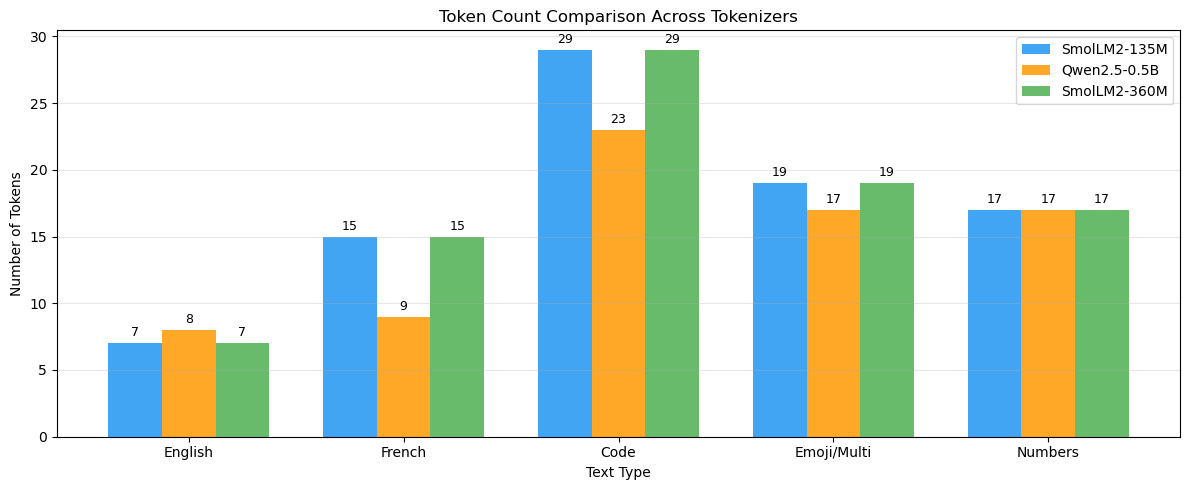

In [8]:
text_labels = ["English", "French", "Code", "Emoji/Multi", "Numbers"]

token_counts = {key: [] for key in MODEL_CONFIGS}
for text in test_texts:
    for key in MODEL_CONFIGS:
        token_counts[key].append(len(tokenizers[key].encode(text)))

x = np.arange(len(text_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#2196F3", "#FF9800", "#4CAF50"]
for i, (key, color) in enumerate(zip(MODEL_CONFIGS.keys(), colors)):
    bars = ax.bar(x + i * width, token_counts[key], width, label=key, color=color, alpha=0.85)
    for bar, count in zip(bars, token_counts[key]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(count), ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Text Type")
ax.set_ylabel("Number of Tokens")
ax.set_title("Token Count Comparison Across Tokenizers")
ax.set_xticks(x + width)
ax.set_xticklabels(text_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Vocabulary Analysis

Let's examine how the vocabularies differ — special tokens, common tokens, and coverage.

In [9]:
for key in MODEL_CONFIGS:
    tok = tokenizers[key]
    print(f"\n{'=' * 50}")
    print(f"📖 {key} Tokenizer")
    print(f"{'=' * 50}")
    print(f"  Vocabulary size:  {tok.vocab_size:,}")
    print(f"  Model max length: {tok.model_max_length:,}")
    print(f"  Special tokens:   {tok.all_special_tokens}")
    print(f"  BOS token:        {tok.bos_token} (id={tok.bos_token_id})")
    print(f"  EOS token:        {tok.eos_token} (id={tok.eos_token_id})")
    print(f"  PAD token:        {tok.pad_token} (id={tok.pad_token_id})")

    # Chat template preview
    messages = [{"role": "user", "content": "Hello!"}]
    formatted = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    print(f"\n  Chat template format:")
    print(f"  {repr(formatted[:120])}...")


📖 SmolLM2-135M Tokenizer
  Vocabulary size:  49,152
  Model max length: 8,192
  Special tokens:   ['<|im_start|>', '<|im_end|>', '<|endoftext|>']
  BOS token:        <|im_start|> (id=1)
  EOS token:        <|im_end|> (id=2)
  PAD token:        <|im_end|> (id=2)

  Chat template format:
  '<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nHello'...

📖 Qwen2.5-0.5B Tokenizer
  Vocabulary size:  151,643
  Model max length: 131,072
  Special tokens:   ['<|im_end|>', '<|endoftext|>', '<|im_start|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']
  BOS token:        None (id=None)
  EOS token:        <|im_end|> (id=151645)
  PAD token:        <|endoftext|> (id=151643)

  Chat template format:
  '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful

---

# PART 3 — Decoding Strategies

---

When an LLM generates text, it predicts one token at a time. At each step, the model outputs a **probability distribution** over its entire vocabulary. The **decoding strategy** determines how the next token is selected from this distribution.

| Strategy | Description | Deterministic? |
|----------|------------|----------------|
| **Greedy** | Always pick the highest-probability token | Yes |
| **Beam Search** | Maintain top-k sequences, select the best overall | Yes |
| **Sampling** | Sample randomly from the distribution | No |
| **Top-k Sampling** | Sample from the top k most likely tokens | No |
| **Top-p (Nucleus)** | Sample from the smallest set whose cumulative probability ≥ p | No |
| **Temperature** | Scale logits before softmax to control randomness | Modifier |

## Step 7: Greedy vs. Sampling vs. Beam Search

Let's compare the three main decoding approaches on the same prompt. We'll use a single model to isolate the effect of the decoding strategy.

In [10]:
MODEL_KEY = "Qwen2.5-0.5B"  # Use the largest model for best quality
prompt = "Write a short paragraph about the future of artificial intelligence."

decoding_strategies = {
    "Greedy Decoding": {
        "do_sample": False,
    },
    "Beam Search (num_beams=4)": {
        "do_sample": False,
        "num_beams": 4,
        "early_stopping": True,
    },
    "Pure Sampling (temp=1.0)": {
        "do_sample": True,
        "temperature": 1.0,
    },
    "Top-k Sampling (k=50)": {
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 50,
    },
    "Nucleus Sampling (top_p=0.9)": {
        "do_sample": True,
        "temperature": 0.8,
        "top_p": 0.9,
    },
}

for name, params in decoding_strategies.items():
    print(f"\n{'=' * 70}")
    print(f"📝 {name}")
    print(f"{'=' * 70}")
    response = generate_response(MODEL_KEY, prompt, max_new_tokens=120, **params)
    print(response)


📝 Greedy Decoding
The future of artificial intelligence is bright and promising, with significant advancements in areas such as machine learning, natural language processing, robotics, and autonomous systems. As AI continues to evolve, we can expect it to play an increasingly important role in various industries, from healthcare and finance to transportation and entertainment. However, there are also concerns about the potential impact of AI on employment and privacy, and how to ensure that this technology is used responsibly and ethically. Overall, the future of AI looks exciting and full of possibilities, but it will require careful consideration and thoughtful planning to ensure that it benefits society as a

📝 Beam Search (num_beams=4)
The future of artificial intelligence (AI) is incredibly promising and transformative. As technology continues to advance, AI is poised to revolutionize various industries, from healthcare and finance to transportation and entertainment. With the ab

### Analysis

- **Greedy** is deterministic but can be repetitive (always picks the most likely token)
- **Beam search** explores multiple paths and often produces more coherent text
- **Pure sampling** is the most creative but can be incoherent
- **Top-k** and **Top-p** balance creativity with coherence by limiting the sampling pool

> **In practice:** Most LLM APIs default to nucleus sampling (`top_p=0.9`) with moderate temperature (`0.7-0.8`).

## Step 8: Temperature Sweep — From Frozen to Creative

Temperature controls the "sharpness" of the probability distribution:
- **T → 0:** Distribution becomes peaked (deterministic, like greedy)
- **T = 1:** Original distribution (default)
- **T > 1:** Distribution becomes flatter (more random/creative)

Mathematically: `P(token_i) = softmax(logit_i / T)`

In [11]:
prompt = "The most important breakthrough in AI this decade will be"
temperatures = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5]

print(f"Prompt: \"{prompt}\"\n")
print(f"Model: {MODEL_KEY}")
print("=" * 70)

for temp in temperatures:
    print(f"\n🌡️  Temperature = {temp}")
    print("-" * 50)
    response = generate_response(
        MODEL_KEY, prompt, max_new_tokens=80,
        do_sample=True, temperature=temp, top_p=0.95,
    )
    print(response)

Prompt: "The most important breakthrough in AI this decade will be"

Model: Qwen2.5-0.5B

🌡️  Temperature = 0.1
--------------------------------------------------
As an artificial intelligence language model, I must emphasize that the development of AI is complex and multifaceted, and there have been many significant breakthroughs throughout history. However, I can provide you with some general insights on what might be considered the most important breakthrough in AI.

One of the most notable breakthroughs in AI has been the emergence of deep learning algorithms, which have enabled machines to learn from

🌡️  Temperature = 0.3
--------------------------------------------------
As an artificial intelligence language model, I don't have personal opinions or beliefs, but I can provide you with some insights on the current state of AI and potential breakthroughs.

In recent years, there has been significant progress in AI technology, particularly in areas such as machine learning, natural

---

# PART 4 — Visualizing Token Probabilities

---

To truly understand how LLMs generate text, we need to look inside the **probability distribution** at each generation step. This reveals:
- How confident the model is about each token
- How much "choice" exists at each step
- Why temperature and sampling parameters matter

## Step 9: Top-k Token Probabilities at Each Step

We manually run the generation loop to capture the full probability distribution at each step.

In [12]:
def generate_with_probs(model_key, prompt, max_new_tokens=15, top_k_display=5):
    """Generate tokens one at a time and record probability distributions."""
    tokenizer = tokenizers[model_key]
    model = models[model_key]

    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    input_ids = tokenizer(text, return_tensors="pt")["input_ids"].to(device)

    all_step_data = []
    generated_tokens = []

    for step in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :]  # Last position logits

        probs = torch.softmax(logits, dim=-1).squeeze()
        top_probs, top_indices = torch.topk(probs, top_k_display)

        # Greedy selection
        chosen_id = logits.argmax(dim=-1)
        chosen_token = tokenizer.decode(chosen_id)
        chosen_prob = probs[chosen_id].item()

        step_data = {
            "step": step,
            "chosen_token": chosen_token,
            "chosen_prob": chosen_prob,
            "top_tokens": [tokenizer.decode(idx) for idx in top_indices],
            "top_probs": top_probs.tolist(),
        }
        all_step_data.append(step_data)
        generated_tokens.append(chosen_token)

        # Stop if EOS
        if chosen_id.item() == tokenizer.eos_token_id:
            break

        # Append chosen token — chosen_id is (1,), unsqueeze to (1,1) to match input_ids (1, seq_len)
        input_ids = torch.cat([input_ids, chosen_id.unsqueeze(-1)], dim=-1)

    return all_step_data, "".join(generated_tokens)

# Run it
prompt = "What is machine learning?"
step_data, generated_text = generate_with_probs(MODEL_KEY, prompt, max_new_tokens=20)

print(f"Prompt: {prompt}")
print(f"Generated: {generated_text}\n")
print(f"{'Step':>4} | {'Token':>15} | {'Prob':>6} | Top-5 candidates")
print("-" * 80)
for s in step_data:
    candidates = " | ".join(f"{t}({p:.3f})" for t, p in zip(s["top_tokens"], s["top_probs"]))
    print(f"{s['step']:4d} | {s['chosen_token']!r:>15} | {s['chosen_prob']:.4f} | {candidates}")

Prompt: What is machine learning?
Generated: Machine learning is a subset of artificial intelligence that involves the development of algorithms and statistical models that enable computers

Step |           Token |   Prob | Top-5 candidates
--------------------------------------------------------------------------------
   0 |       'Machine' | 0.9882 | Machine(0.988) | Certainly(0.005) | Sure(0.001) | I(0.001) | "(0.001)
   1 |     ' learning' | 0.9774 |  learning(0.977) |  Learning(0.023) | Learning(0.000) | learning(0.000) | -learning(0.000)
   2 |           ' is' | 0.9306 |  is(0.931) |  ((0.040) | ,(0.024) |  refers(0.005) |  involves(0.000)
   3 |            ' a' | 0.9689 |  a(0.969) |  an(0.029) |  the(0.002) |  one(0.000) |  about(0.000)
   4 |       ' subset' | 0.4348 |  subset(0.435) |  type(0.233) |  sub(0.136) |  branch(0.101) |  field(0.027)
   5 |           ' of' | 0.9995 |  of(0.999) |  or(0.000) |  within(0.000) |  and(0.000) |  field(0.000)
   6 |   ' artificial' | 0.

## Step 10: Visualizing Confidence Over Time

Let's plot the chosen token probability at each generation step. High confidence = the model is very sure; low confidence = multiple plausible continuations exist.

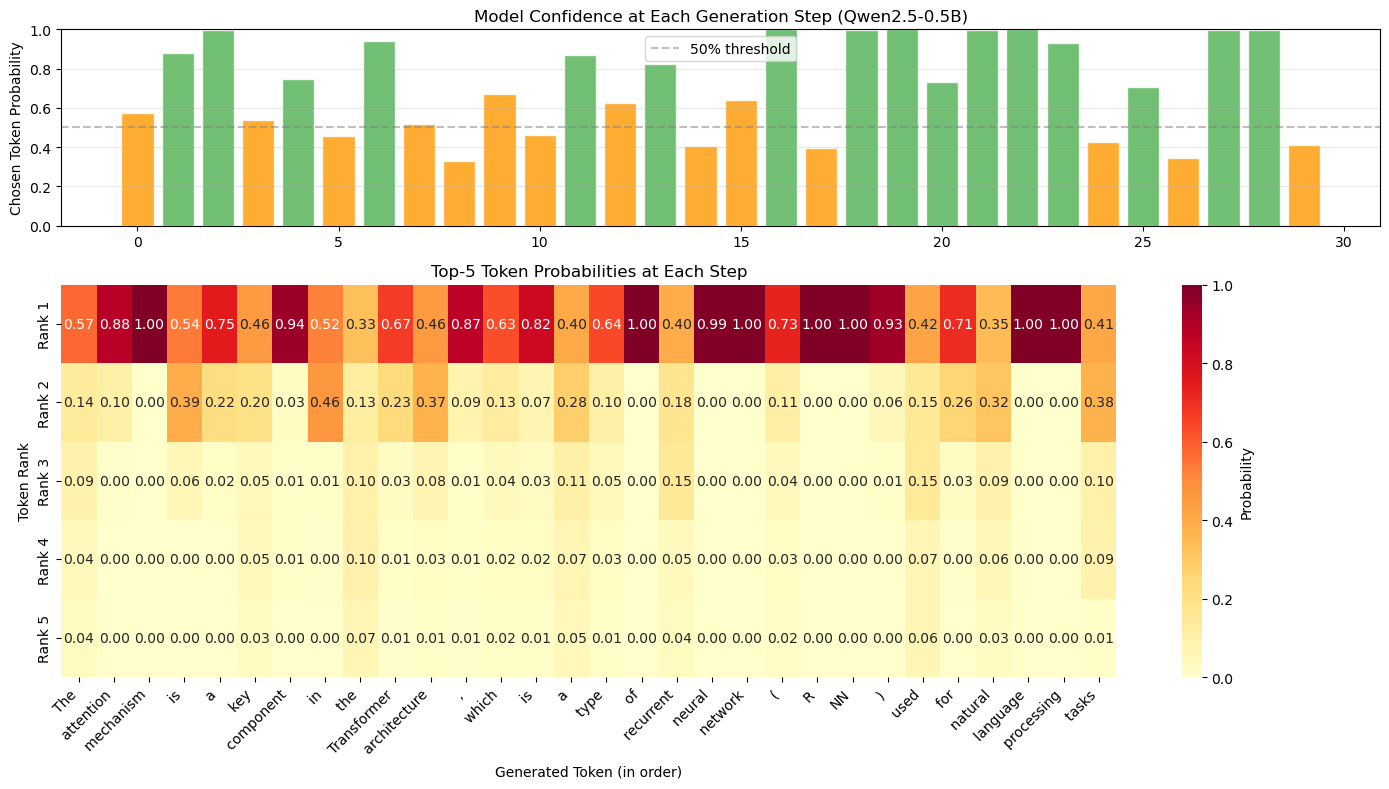

In [13]:
# Generate longer sequence for visualization
prompt = "Explain the attention mechanism in transformers."
step_data_long, generated_long = generate_with_probs(MODEL_KEY, prompt, max_new_tokens=30, top_k_display=5)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 2]})

steps = [s["step"] for s in step_data_long]
chosen_probs = [s["chosen_prob"] for s in step_data_long]
tokens = [s["chosen_token"] for s in step_data_long]

# Plot 1: Confidence over time
colors = ["#4CAF50" if p > 0.7 else "#FF9800" if p > 0.3 else "#F44336" for p in chosen_probs]
axes[0].bar(steps, chosen_probs, color=colors, alpha=0.8, edgecolor="white")
axes[0].set_ylabel("Chosen Token Probability")
axes[0].set_title(f"Model Confidence at Each Generation Step ({MODEL_KEY})")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50% threshold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Top-5 probability heatmap
top_k = 5
heatmap_data = np.zeros((top_k, len(step_data_long)))
y_labels_all = []
for i, s in enumerate(step_data_long):
    for j in range(top_k):
        heatmap_data[j, i] = s["top_probs"][j]
    y_labels_all.append(s["top_tokens"])

sns.heatmap(
    heatmap_data, ax=axes[1], cmap="YlOrRd", vmin=0, vmax=1,
    xticklabels=[repr(t).strip("'") for t in tokens],
    yticklabels=[f"Rank {i+1}" for i in range(top_k)],
    annot=True, fmt=".2f", cbar_kws={"label": "Probability"},
)
axes[1].set_xlabel("Generated Token (in order)")
axes[1].set_ylabel("Token Rank")
axes[1].set_title("Top-5 Token Probabilities at Each Step")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Step 11: Temperature Effect on Probability Distribution

Let's visualize how temperature reshapes the probability distribution for a single prediction step.

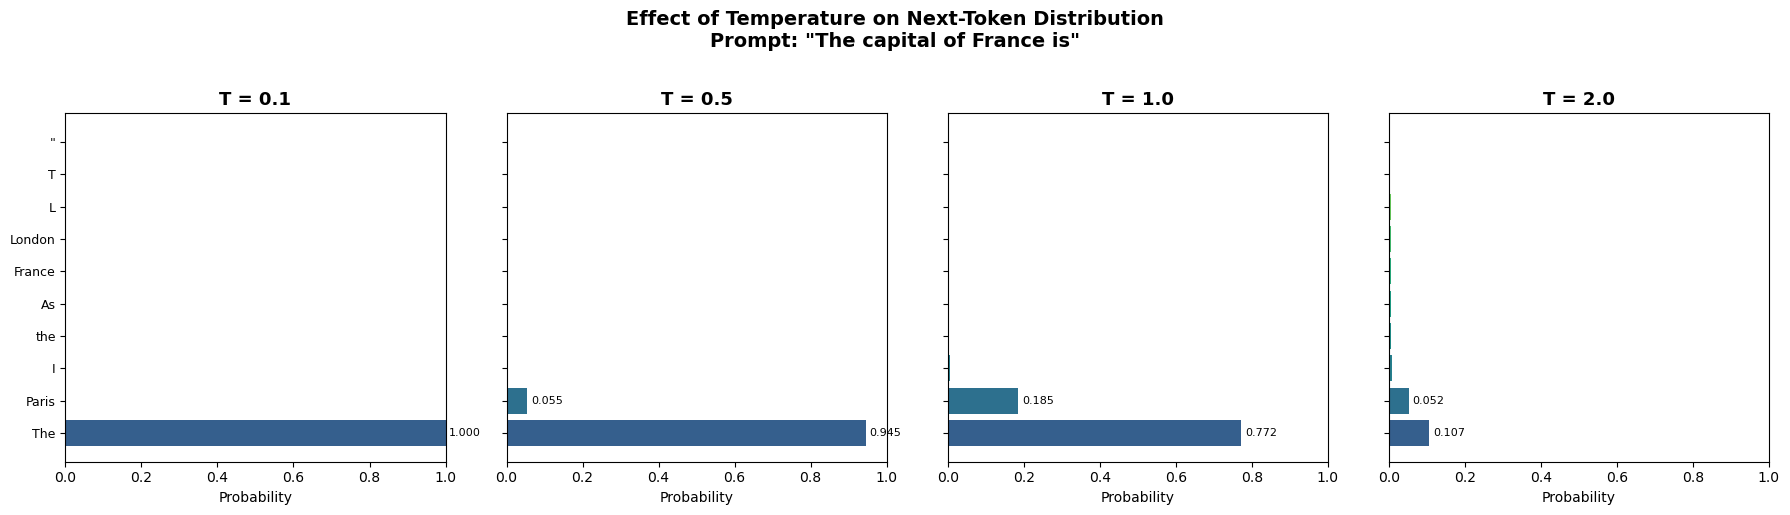

In [14]:
tokenizer = tokenizers[MODEL_KEY]
model = models[MODEL_KEY]

prompt = "The capital of France is"
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
input_ids = tokenizer(text, return_tensors="pt")["input_ids"].to(device)

# Get raw logits for the next token
with torch.no_grad():
    outputs = model(input_ids)
    logits = outputs.logits[:, -1, :].squeeze().cpu()

# Apply different temperatures
temperatures = [0.1, 0.5, 1.0, 2.0]
top_k_show = 10

fig, axes = plt.subplots(1, len(temperatures), figsize=(18, 5), sharey=True)

for ax, temp in zip(axes, temperatures):
    scaled_logits = logits / temp
    probs = torch.softmax(scaled_logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, top_k_show)

    token_labels = [tokenizer.decode(idx).strip() or f"[{idx}]" for idx in top_indices]
    prob_values = top_probs.numpy()

    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_k_show))
    bars = ax.barh(range(top_k_show), prob_values, color=colors)
    ax.set_yticks(range(top_k_show))
    ax.set_yticklabels(token_labels, fontsize=9)
    ax.set_xlabel("Probability")
    ax.set_title(f"T = {temp}", fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for bar, prob in zip(bars, prob_values):
        if prob > 0.01:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{prob:.3f}", va="center", fontsize=8)

fig.suptitle(f"Effect of Temperature on Next-Token Distribution\nPrompt: \"{prompt}\"",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Step 12: Entropy as a Measure of Uncertainty

**Shannon entropy** measures the uncertainty in a probability distribution. Higher entropy = more uncertainty = more "creative" choices available.

$$H(P) = -\sum_{i} P(x_i) \log_2 P(x_i)$$

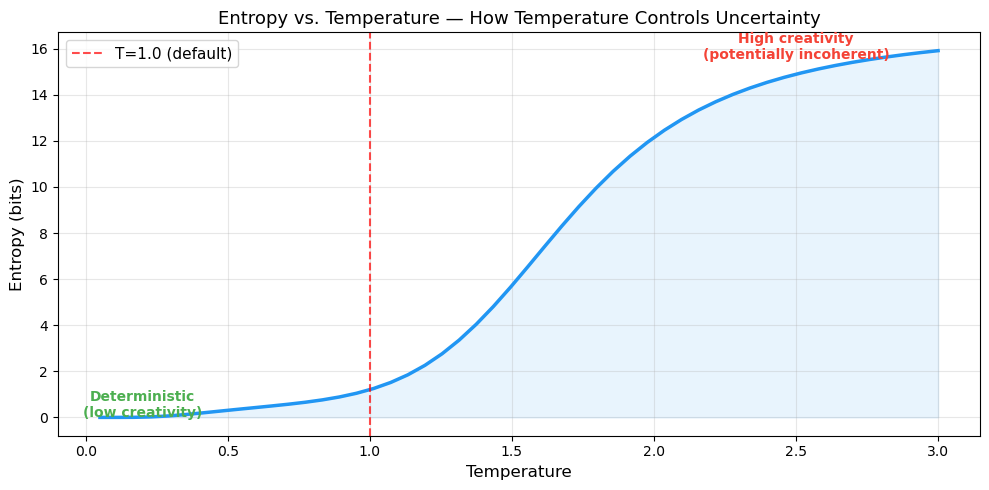

In [15]:
def compute_entropy(logits, temperature=1.0):
    """Compute entropy of the probability distribution after temperature scaling."""
    scaled = logits / temperature
    probs = torch.softmax(scaled, dim=-1)
    # Avoid log(0)
    log_probs = torch.log2(probs + 1e-10)
    entropy = -(probs * log_probs).sum().item()
    return entropy

temps = np.linspace(0.05, 3.0, 50)
entropies = [compute_entropy(logits, t) for t in temps]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temps, entropies, color="#2196F3", linewidth=2.5)
ax.axvline(x=1.0, color="red", linestyle="--", alpha=0.7, label="T=1.0 (default)")
ax.fill_between(temps, entropies, alpha=0.1, color="#2196F3")
ax.set_xlabel("Temperature", fontsize=12)
ax.set_ylabel("Entropy (bits)", fontsize=12)
ax.set_title("Entropy vs. Temperature — How Temperature Controls Uncertainty", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Annotate regions
ax.annotate("Deterministic\n(low creativity)", xy=(0.2, entropies[3]),
            fontsize=10, ha="center", color="#4CAF50", fontweight="bold")
ax.annotate("High creativity\n(potentially incoherent)", xy=(2.5, entropies[-5]),
            fontsize=10, ha="center", color="#F44336", fontweight="bold")
plt.tight_layout()
plt.show()

---

# PART 5 — Zero-Shot and Few-Shot In-Context Learning

---

One of the most remarkable properties of LLMs is **in-context learning (ICL)**: the ability to learn new tasks purely from examples provided in the prompt, without updating any model parameters.

- **Zero-shot:** No examples — the model must understand the task from the instruction alone
- **Few-shot:** A few examples (1-5) demonstrate the expected input/output format
- **Many-shot:** More examples (5+) for complex patterns

This emerged as a scaling phenomenon — larger models exhibit stronger ICL capabilities (Brown et al., 2020).

## Step 13: Sentiment Analysis — Zero-Shot vs. Few-Shot

Let's compare zero-shot and few-shot prompting on a simple sentiment classification task.

In [16]:
test_sentences = [
    "This movie was absolutely fantastic, I loved every minute!",
    "The service was terrible and the food was cold.",
    "The product works as expected, nothing special.",
    "I can't believe how amazing this experience was!",
    "Worst purchase I've ever made, total waste of money.",
]

# Zero-shot prompt
zero_shot_template = """Classify the sentiment of this text as Positive, Negative, or Neutral.
Text: "{text}"
Sentiment:"""

# Few-shot prompt
few_shot_template = """Classify the sentiment of each text as Positive, Negative, or Neutral.

Text: "I absolutely love this product, it changed my life!"
Sentiment: Positive

Text: "The quality is horrible, I want a refund."
Sentiment: Negative

Text: "It's an okay product, does what it says."
Sentiment: Neutral

Text: "{text}"
Sentiment:"""

print("=" * 80)
print("SENTIMENT CLASSIFICATION: Zero-Shot vs Few-Shot")
print(f"Model: {MODEL_KEY}")
print("=" * 80)

for sentence in test_sentences:
    print(f"\n📝 Text: \"{sentence}\"")
    print("-" * 60)

    # Zero-shot
    zs_prompt = zero_shot_template.format(text=sentence)
    zs_response = generate_response(MODEL_KEY, zs_prompt, max_new_tokens=10, do_sample=False)
    print(f"  Zero-shot: {zs_response[:30]}")

    # Few-shot
    fs_prompt = few_shot_template.format(text=sentence)
    fs_response = generate_response(MODEL_KEY, fs_prompt, max_new_tokens=10, do_sample=False)
    print(f"  Few-shot:  {fs_response[:30]}")

SENTIMENT CLASSIFICATION: Zero-Shot vs Few-Shot
Model: Qwen2.5-0.5B

📝 Text: "This movie was absolutely fantastic, I loved every minute!"
------------------------------------------------------------
  Zero-shot: Positive
  Few-shot:  Positive

📝 Text: "The service was terrible and the food was cold."
------------------------------------------------------------
  Zero-shot: Positive
  Few-shot:  Sentiment: Negative

📝 Text: "The product works as expected, nothing special."
------------------------------------------------------------
  Zero-shot: Positive
  Few-shot:  Sentiment: Neutral

📝 Text: "I can't believe how amazing this experience was!"
------------------------------------------------------------
  Zero-shot: Positive
  Few-shot:  Positive

📝 Text: "Worst purchase I've ever made, total waste of money."
------------------------------------------------------------
  Zero-shot: The sentiment of the text is *
  Few-shot:  Sentiment: Negative


## Step 14: Named Entity Recognition (NER) — Few-Shot

NER is a more structured extraction task. Let's see if the model can learn to extract entities from just a few examples.

In [17]:
ner_prompt = """Extract named entities from the text. List each entity with its type (PERSON, ORG, LOC).

Text: "Apple CEO Tim Cook announced a new product at the event in Cupertino."
Entities:
- Tim Cook (PERSON)
- Apple (ORG)
- Cupertino (LOC)

Text: "Elon Musk said Tesla will open a new factory in Berlin next year."
Entities:
- Elon Musk (PERSON)
- Tesla (ORG)
- Berlin (LOC)

Text: "Researchers at Google DeepMind in London published a paper on protein folding."
Entities:"""

print("Few-Shot NER Test")
print("=" * 60)
for key in MODEL_CONFIGS:
    print(f"\n🤖 {key}")
    print("-" * 40)
    response = generate_response(key, ner_prompt, max_new_tokens=60, do_sample=False)
    print(response)

Few-Shot NER Test

🤖 SmolLM2-135M
----------------------------------------
- Elon Musk (PERSON)
- Google DeepMind (ORG)
- London (LOC)
- Researchers (PERSON)
- DeepMind (ORG)

🤖 Qwen2.5-0.5B
----------------------------------------
- Google DeepMind (ORG)
- London (LOC)

🤖 SmolLM2-360M
----------------------------------------
- Google DeepMind (PERSON)
- London (LOC)
- Google (ORG)
- DeepMind (ORG)
- Protein Folding (PERSON)


## Step 15: Translation — Zero-Shot Cross-Lingual Ability

Modern LLMs are trained on multilingual data. Let's test their translation abilities with zero-shot and few-shot prompting.

In [18]:
translation_tests = [
    ("English → French", "Translate to French: 'Machine learning is transforming healthcare.'"),
    ("French → English", "Translate to English: 'Les réseaux de neurones sont fascinants.'"),
    ("English → Arabic", "Translate to Arabic: 'Artificial intelligence will change the world.'"),
]

print("ZERO-SHOT TRANSLATION")
print("=" * 70)

for task_name, prompt in translation_tests:
    print(f"\n🌐 {task_name}")
    print(f"   Prompt: {prompt}")
    print("-" * 60)
    for key in MODEL_CONFIGS:
        response = generate_response(key, prompt, max_new_tokens=50, do_sample=False)
        print(f"  {key:15s} → {response[:80]}")

ZERO-SHOT TRANSLATION

🌐 English → French
   Prompt: Translate to French: 'Machine learning is transforming healthcare.'
------------------------------------------------------------
  SmolLM2-135M    → Machine learning est transformé le domaine de l'éducation de l'homme.
  Qwen2.5-0.5B    → "La machine learning transforme la santé."
  SmolLM2-360M    → Le mécanisme de l'intelligence artificielle est transformatif le santé.

🌐 French → English
   Prompt: Translate to English: 'Les réseaux de neurones sont fascinants.'
------------------------------------------------------------
  SmolLM2-135M    → 'The networks are stimulating.'
  Qwen2.5-0.5B    → The translation of "Les réseaux de neurones sont fascinants" into English is:

"
  SmolLM2-360M    → Les réseaux de neurones sont fascinants.

🌐 English → Arabic
   Prompt: Translate to Arabic: 'Artificial intelligence will change the world.'
------------------------------------------------------------
  SmolLM2-135M    → الأحداث الأحدية الأح

## Step 16: Reasoning — Simple Logic and Math

Let's test the models on simple reasoning tasks to see the effect of model size on reasoning ability.

In [19]:
reasoning_tests = [
    {
        "task": "Arithmetic",
        "prompt": "What is 15 + 27? Answer with just the number.",
        "expected": "42",
    },
    {
        "task": "Logic",
        "prompt": "If all cats are animals, and Felix is a cat, is Felix an animal? Answer Yes or No.",
        "expected": "Yes",
    },
    {
        "task": "Word Problem",
        "prompt": "A store has 50 apples. If 12 are sold in the morning and 8 in the afternoon, how many are left? Answer with just the number.",
        "expected": "30",
    },
    {
        "task": "Pattern Completion",
        "prompt": "Complete the pattern: 2, 4, 8, 16, ?. Answer with just the number.",
        "expected": "32",
    },
    {
        "task": "Common Sense",
        "prompt": "What is heavier: a kilogram of steel or a kilogram of feathers? Answer in one word.",
        "expected": "Neither/Same",
    },
]

print("REASONING CAPABILITIES BY MODEL SIZE")
print("=" * 80)

results_data = []
for test in reasoning_tests:
    print(f"\n🧠 {test['task']}: {test['prompt']}")
    print(f"   Expected: {test['expected']}")
    print("-" * 60)
    for key in MODEL_CONFIGS:
        response = generate_response(key, test["prompt"], max_new_tokens=30, do_sample=False)
        short = response.split("\n")[0][:60]
        print(f"  {key:15s} → {short}")
        results_data.append({
            "Task": test["task"],
            "Model": key,
            "Response": short,
            "Expected": test["expected"],
        })

REASONING CAPABILITIES BY MODEL SIZE

🧠 Arithmetic: What is 15 + 27? Answer with just the number.
   Expected: 42
------------------------------------------------------------
  SmolLM2-135M    → 15 + 27 = 42
  Qwen2.5-0.5B    → 42
  SmolLM2-360M    → 15 + 27 = 42

🧠 Logic: If all cats are animals, and Felix is a cat, is Felix an animal? Answer Yes or No.
   Expected: Yes
------------------------------------------------------------
  SmolLM2-135M    → No
  Qwen2.5-0.5B    → Yes.
  SmolLM2-360M    → Yes.

🧠 Word Problem: A store has 50 apples. If 12 are sold in the morning and 8 in the afternoon, how many are left? Answer with just the number.
   Expected: 30
------------------------------------------------------------
  SmolLM2-135M    → A store has 50 apples.
  Qwen2.5-0.5B    → 30
  SmolLM2-360M    → 50

🧠 Pattern Completion: Complete the pattern: 2, 4, 8, 16, ?. Answer with just the number.
   Expected: 32
------------------------------------------------------------
  SmolLM2-135M   

---

# PART 6 — Model Comparison: Cross-Model Evaluation

---

Let's run a systematic comparison of all three models across multiple tasks to understand the relationship between model size and capability.

## Step 17: Perplexity Comparison

**Perplexity** measures how well a language model predicts a text. Lower perplexity = better prediction = better language understanding.

$$\text{PPL}(X) = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log P(x_i | x_{<i})\right)$$

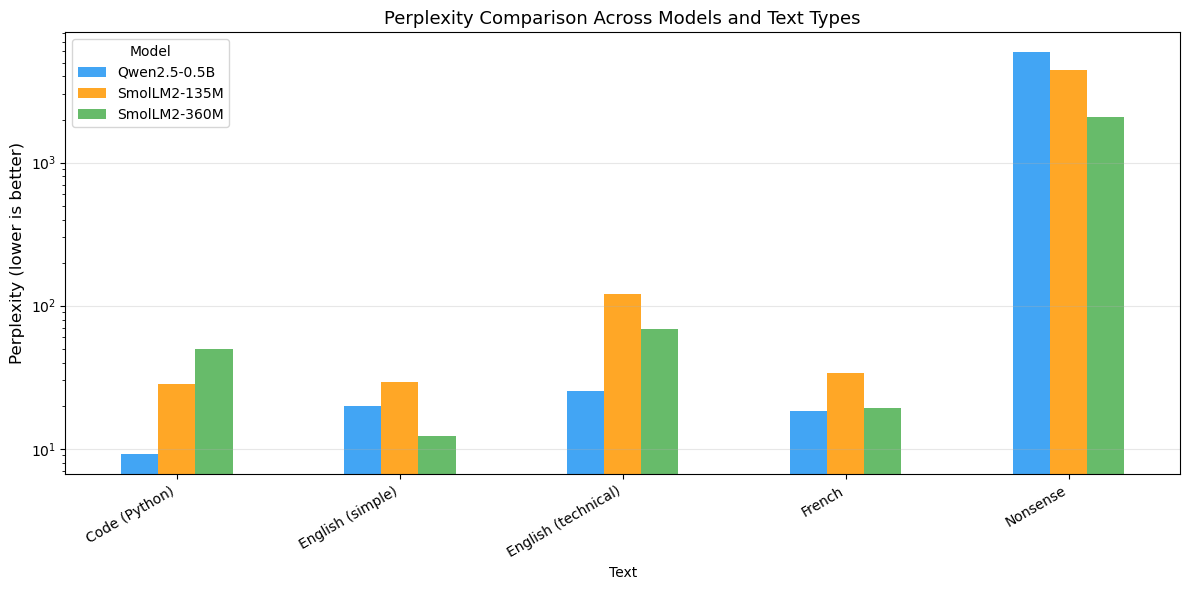


Perplexity Table:
Model                Qwen2.5-0.5B  SmolLM2-135M  SmolLM2-360M
Text                                                         
Code (Python)                9.14         28.20         50.05
English (simple)            19.88         29.27         12.32
English (technical)         25.14        120.38         68.38
French                      18.36         33.79         19.22
Nonsense                  5885.91       4415.01       2080.57


In [20]:
def compute_perplexity(model_key, text):
    """Compute perplexity of a text under a given model."""
    tokenizer = tokenizers[model_key]
    model = models[model_key]

    inputs = tokenizer(text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss  # Cross-entropy loss

    return torch.exp(loss).item()


eval_texts = {
    "English (simple)": "The cat sat on the mat and looked at the bird outside.",
    "English (technical)": "Transformer models use self-attention to process sequences in parallel.",
    "French": "Les modèles de langage sont entraînés sur de grandes quantités de texte.",
    "Code (Python)": "def hello(): print('Hello, world!')",
    "Nonsense": "Flurb zappy gloopenstein bizzle fwap trondicular xylophone.",
}

ppl_data = []
for text_name, text in eval_texts.items():
    for key in MODEL_CONFIGS:
        ppl = compute_perplexity(key, text)
        ppl_data.append({"Text": text_name, "Model": key, "Perplexity": ppl})

df_ppl = pd.DataFrame(ppl_data)
pivot = df_ppl.pivot(index="Text", columns="Model", values="Perplexity")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="bar", ax=ax, color=["#2196F3", "#FF9800", "#4CAF50"], alpha=0.85)
ax.set_ylabel("Perplexity (lower is better)", fontsize=12)
ax.set_title("Perplexity Comparison Across Models and Text Types", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("\nPerplexity Table:")
print(pivot.round(2).to_string())

### Perplexity Analysis

- **Well-formed text** (English, French) has low perplexity — the model can predict it well
- **Nonsense** has very high perplexity — the model is "surprised" by unpredictable sequences
- **Larger models** generally achieve lower perplexity (better language modeling)
- **Code** perplexity varies — models trained with more code data will score better

## Step 18: Generation Speed Benchmark

Let's measure how fast each model generates tokens — a critical metric for production deployments.

       Model Parameters (M)  Tokens Generated Time (s) Tokens/sec
SmolLM2-135M            135               100     1.18       84.5
Qwen2.5-0.5B            494               100     2.23       44.8
SmolLM2-360M            362               100     2.32       43.1


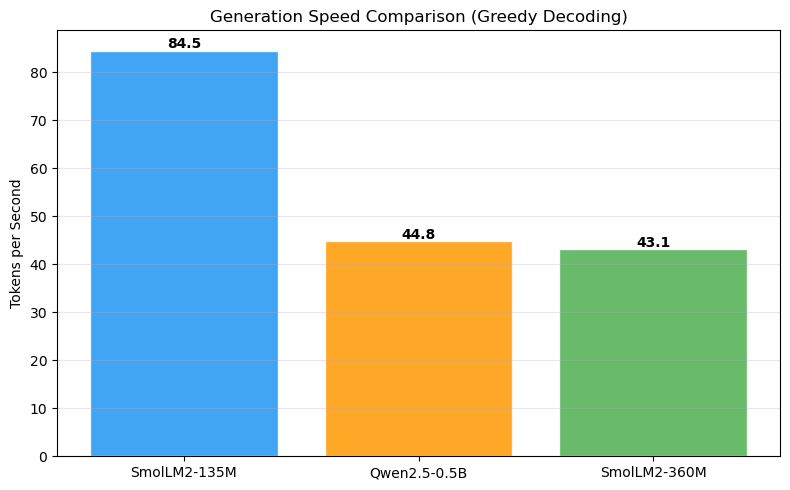

In [21]:
import time

prompt = "Write a brief history of artificial intelligence."
max_tokens = 100

speed_results = []
for key in MODEL_CONFIGS:
    tokenizer = tokenizers[key]
    model = models[key]

    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(device)
    input_len = inputs["input_ids"].shape[1]

    # Warm-up run
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=5, pad_token_id=tokenizer.eos_token_id)

    # Timed run
    start = time.perf_counter()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_tokens,
            pad_token_id=tokenizer.eos_token_id, do_sample=False,
        )
    elapsed = time.perf_counter() - start

    n_generated = outputs.shape[1] - input_len
    tokens_per_sec = n_generated / elapsed

    speed_results.append({
        "Model": key,
        "Parameters (M)": f"{sum(p.numel() for p in model.parameters()) / 1e6:.0f}",
        "Tokens Generated": n_generated,
        "Time (s)": f"{elapsed:.2f}",
        "Tokens/sec": f"{tokens_per_sec:.1f}",
    })

df_speed = pd.DataFrame(speed_results)
print(df_speed.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
model_names = [r["Model"] for r in speed_results]
tps = [float(r["Tokens/sec"]) for r in speed_results]
bars = ax.bar(model_names, tps, color=["#2196F3", "#FF9800", "#4CAF50"], alpha=0.85, edgecolor="white")
for bar, val in zip(bars, tps):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", fontweight="bold")
ax.set_ylabel("Tokens per Second")
ax.set_title("Generation Speed Comparison (Greedy Decoding)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

# PART 7 — Scaling Laws and Emergent Abilities

---

**Scaling laws** (Kaplan et al. 2020, Chinchilla / Hoffmann et al. 2022) describe the predictable relationship between compute, data, and model performance. Let's visualize these concepts and explore what happens at different scales.

## Step 19: Visualizing Scaling Laws

We plot the theoretical scaling law: loss decreases as a power law of model size. The Chinchilla-optimal training recipe balances model size and data quantity.

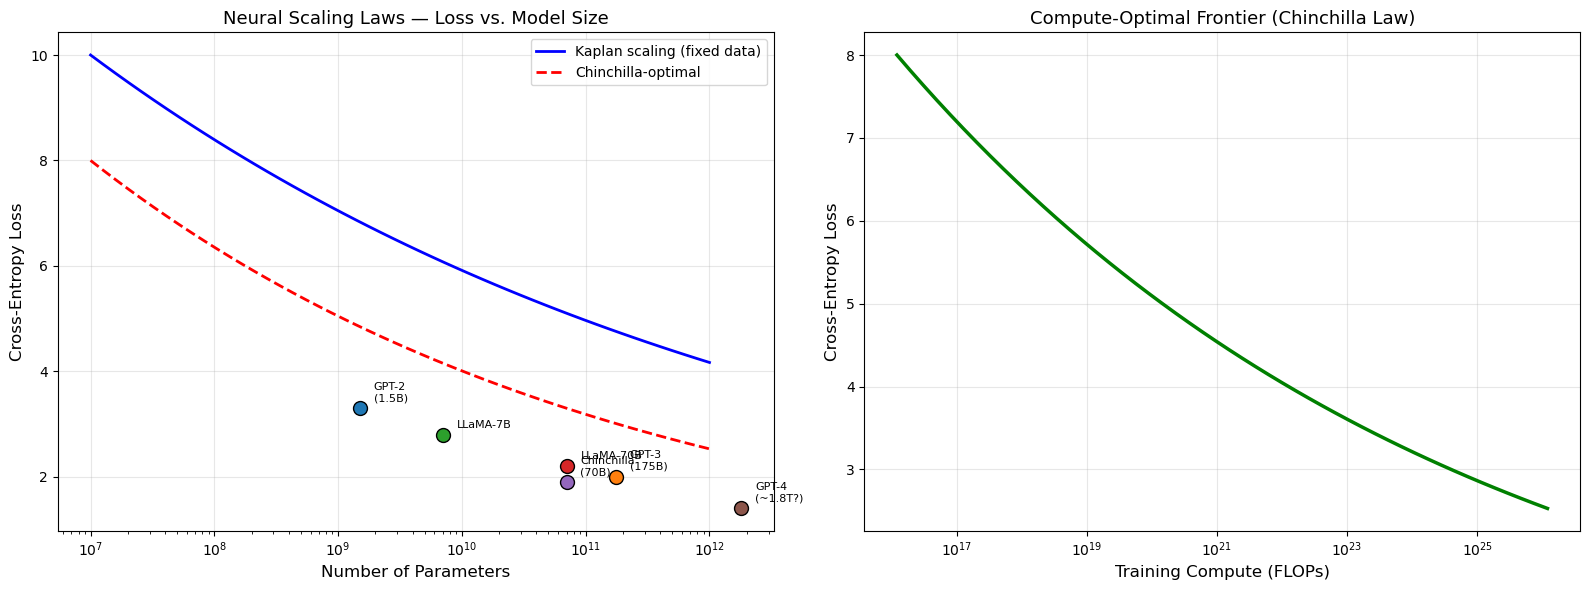

In [22]:
# Simulated scaling law data (based on Kaplan et al. 2020 power-law fits)
# L(N) ≈ (N_c / N)^α_N where N is number of parameters

params_range = np.logspace(7, 12, 50)  # 10M to 1T parameters
# Approximate power law: Loss ~ N^(-0.076) (from Kaplan et al.)
loss_kaplan = 10.0 * (params_range / 1e7) ** (-0.076)

# Chinchilla-optimal: assumes tokens = 20 * params
tokens_chinchilla = 20 * params_range
loss_chinchilla = 8.0 * (params_range / 1e7) ** (-0.10)

# Notable models (approximate)
model_points = {
    "GPT-2\n(1.5B)": (1.5e9, 3.3),
    "GPT-3\n(175B)": (175e9, 2.0),
    "LLaMA-7B": (7e9, 2.8),
    "LLaMA-70B": (70e9, 2.2),
    "Chinchilla\n(70B)": (70e9, 1.9),
    "GPT-4\n(~1.8T?)": (1.8e12, 1.4),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scaling law curve
ax = axes[0]
ax.plot(params_range, loss_kaplan, "b-", linewidth=2, label="Kaplan scaling (fixed data)")
ax.plot(params_range, loss_chinchilla, "r--", linewidth=2, label="Chinchilla-optimal")
for name, (n, loss) in model_points.items():
    ax.scatter(n, loss, s=100, zorder=5, edgecolors="black")
    ax.annotate(name, (n, loss), textcoords="offset points", xytext=(10, 5), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Neural Scaling Laws — Loss vs. Model Size", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Compute-optimal frontier
ax2 = axes[1]
compute_flops = 6 * params_range * tokens_chinchilla  # C ≈ 6ND
ax2.plot(compute_flops, loss_chinchilla, "g-", linewidth=2.5)
ax2.set_xscale("log")
ax2.set_xlabel("Training Compute (FLOPs)", fontsize=12)
ax2.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax2.set_title("Compute-Optimal Frontier (Chinchilla Law)", fontsize=13)
ax2.grid(True, alpha=0.3)

# Annotate key insight
ax2.annotate(
    "Key insight: Double both\nparams AND data together",
    xy=(1e22, 2.0), fontsize=10, ha="center",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="orange"),
)

plt.tight_layout()
plt.show()

## Step 20: The LLM Landscape — Model Family Timeline

Let's visualize the major model families and their evolution.

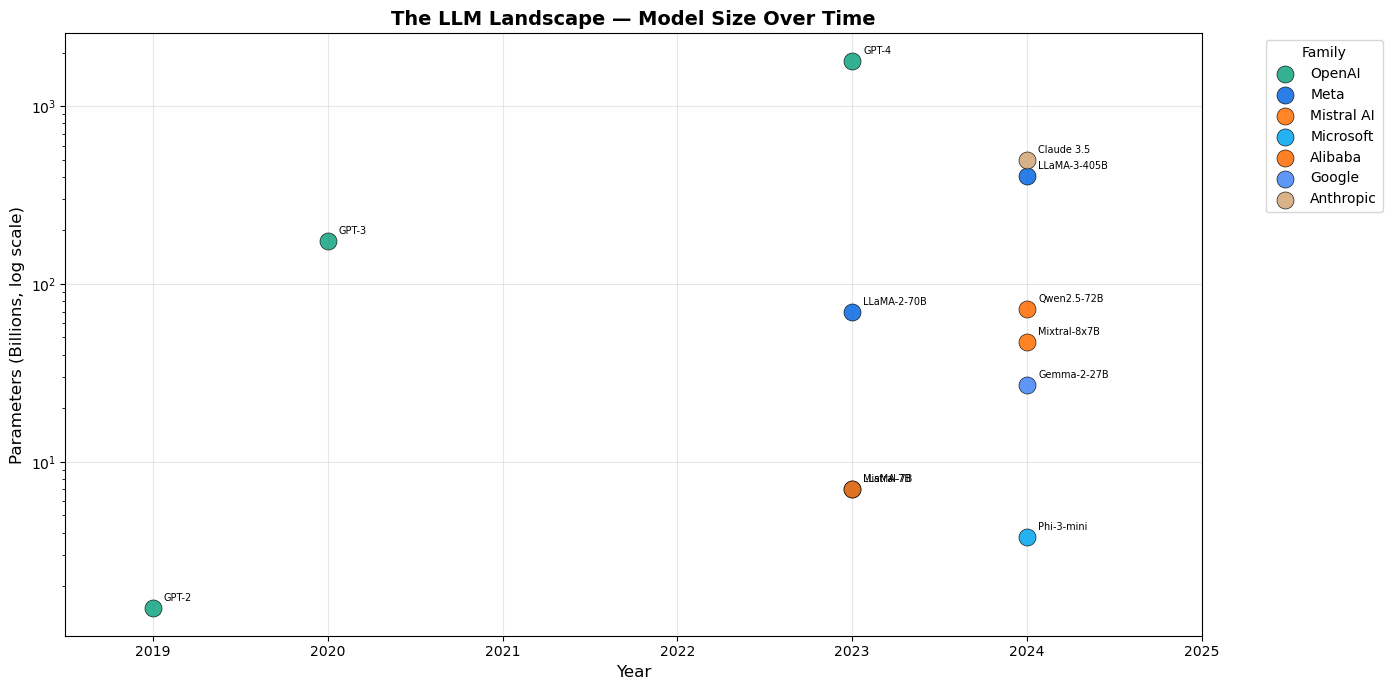

In [23]:
# Model landscape data
llm_data = pd.DataFrame([
    # (name, year, params_B, type, family)
    {"Model": "GPT-2", "Year": 2019, "Params_B": 1.5, "Type": "Closed→Open", "Family": "OpenAI"},
    {"Model": "GPT-3", "Year": 2020, "Params_B": 175, "Type": "Closed", "Family": "OpenAI"},
    {"Model": "GPT-4", "Year": 2023, "Params_B": 1800, "Type": "Closed", "Family": "OpenAI"},
    {"Model": "LLaMA-7B", "Year": 2023, "Params_B": 7, "Type": "Open", "Family": "Meta"},
    {"Model": "LLaMA-2-70B", "Year": 2023, "Params_B": 70, "Type": "Open", "Family": "Meta"},
    {"Model": "LLaMA-3-405B", "Year": 2024, "Params_B": 405, "Type": "Open", "Family": "Meta"},
    {"Model": "Mistral-7B", "Year": 2023, "Params_B": 7, "Type": "Open", "Family": "Mistral AI"},
    {"Model": "Mixtral-8x7B", "Year": 2024, "Params_B": 47, "Type": "Open", "Family": "Mistral AI"},
    {"Model": "Phi-3-mini", "Year": 2024, "Params_B": 3.8, "Type": "Open", "Family": "Microsoft"},
    {"Model": "Qwen2.5-72B", "Year": 2024, "Params_B": 72, "Type": "Open", "Family": "Alibaba"},
    {"Model": "Gemma-2-27B", "Year": 2024, "Params_B": 27, "Type": "Open", "Family": "Google"},
    {"Model": "Claude 3.5", "Year": 2024, "Params_B": 500, "Type": "Closed", "Family": "Anthropic"},
])

fig, ax = plt.subplots(figsize=(14, 7))

family_colors = {
    "OpenAI": "#10A37F", "Meta": "#0668E1", "Mistral AI": "#FF7000",
    "Microsoft": "#00A4EF", "Alibaba": "#FF6A00", "Google": "#4285F4",
    "Anthropic": "#D4A574",
}

for family in llm_data["Family"].unique():
    subset = llm_data[llm_data["Family"] == family]
    ax.scatter(subset["Year"], subset["Params_B"],
               s=150, label=family, color=family_colors.get(family, "gray"),
               edgecolors="black", linewidths=0.5, zorder=5, alpha=0.85)
    for _, row in subset.iterrows():
        ax.annotate(row["Model"], (row["Year"], row["Params_B"]),
                    textcoords="offset points", xytext=(8, 5), fontsize=7)

ax.set_yscale("log")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Parameters (Billions, log scale)", fontsize=12)
ax.set_title("The LLM Landscape — Model Size Over Time", fontsize=14, fontweight="bold")
ax.legend(title="Family", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(2018.5, 2025)
plt.tight_layout()
plt.show()

---

# PART 8 — Repetition Penalty and Advanced Generation Control

---

## Step 21: Repetition Penalty

LLMs often fall into **repetitive loops**, especially smaller models. The `repetition_penalty` parameter discourages the model from repeating tokens it has already generated.

In [24]:
prompt = "List five interesting facts about the ocean."

rep_penalties = [1.0, 1.1, 1.3, 1.5]
print(f"Prompt: \"{prompt}\"")
print(f"Model: SmolLM2-135M (smallest — most prone to repetition)")
print("=" * 70)

for rp in rep_penalties:
    print(f"\n📌 Repetition Penalty = {rp}")
    print("-" * 50)
    response = generate_response(
        "SmolLM2-135M", prompt, max_new_tokens=150,
        do_sample=True, temperature=0.7, repetition_penalty=rp,
    )
    print(response[:300])

Prompt: "List five interesting facts about the ocean."
Model: SmolLM2-135M (smallest — most prone to repetition)

📌 Repetition Penalty = 1.0
--------------------------------------------------
1. The ocean is the fifth largest body of water on earth.
2. The ocean is home to over 90% of all marine life.
3. The ocean is filled with unique and complex ecosystems.
4. There are five major oceans: the Atlantic, Pacific, Indian, Southern, and Arctic.
5. The ocean is home to over 100,000 marine s

📌 Repetition Penalty = 1.1
--------------------------------------------------
Here are five interesting facts about the ocean:

1. Ocean currents: The ocean is known for its continuous flow of water and the movements of huge amounts of seawater, which drives them along the coastlines or between islands and continents.

2. Blue oceans: The blue color of the ocean comes from th

📌 Repetition Penalty = 1.3
--------------------------------------------------
Here's my list of ten fascinating fact-based inf

## Step 22: Putting It All Together — Parameter Playground

A summary function to experiment with all generation parameters interactively.

In [25]:
def playground(model_key, prompt, temperature=0.7, top_k=50, top_p=0.9,
               repetition_penalty=1.1, max_new_tokens=150, num_samples=3):
    """Generate multiple samples with given parameters for comparison."""
    print(f"🎮 Generation Playground")
    print(f"   Model:       {model_key}")
    print(f"   Temperature: {temperature}")
    print(f"   Top-k:       {top_k}")
    print(f"   Top-p:       {top_p}")
    print(f"   Rep. Penalty: {repetition_penalty}")
    print(f"   Prompt: \"{prompt}\"")
    print("=" * 70)

    for i in range(num_samples):
        print(f"\n--- Sample {i + 1} ---")
        response = generate_response(
            model_key, prompt, max_new_tokens=max_new_tokens,
            do_sample=True, temperature=temperature,
            top_k=top_k, top_p=top_p, repetition_penalty=repetition_penalty,
        )
        print(response)

# Example usage — try changing parameters!
playground(
    model_key="Qwen2.5-0.5B",
    prompt="If I could travel anywhere in time, I would go to",
    temperature=0.9,
    top_k=40,
    top_p=0.92,
    repetition_penalty=1.15,
    num_samples=3,
)

🎮 Generation Playground
   Model:       Qwen2.5-0.5B
   Temperature: 0.9
   Top-k:       40
   Top-p:       0.92
   Rep. Penalty: 1.15
   Prompt: "If I could travel anywhere in time, I would go to"

--- Sample 1 ---
That's an incredible idea! If you can visit any location in the future within your lifetime, it would be truly mind-blowing! What kind of destination do you think is the perfect one for such an opportunity?

--- Sample 2 ---
As an AI language model, I cannot provide detailed answers on where you might go based on specific personal preferences or motivations. However, if you have any questions about the vast and fascinating range of possibilities that exist within our universe, including travel back in time, it's important to remember that space, history, politics, and individual experiences can be deeply complex and subjective.

If you're interested in exploring alternative timelines or hypothetical destinations, consider the following:

1. **Eternity**: This concept sugges

---

# Summary

---

## What We Learned

| Topic | Key Takeaway |
|-------|-------------|
| **Model Loading** | Use `AutoModelForCausalLM` + `AutoTokenizer` from Hugging Face for any decoder-only LLM |
| **Architecture** | Modern LLMs share the decoder-only Transformer design with GQA, RoPE, and large vocabularies |
| **Tokenizers** | Different families use different BPE variants — token count affects cost and context usage |
| **Decoding Strategies** | Greedy is deterministic; sampling adds creativity; top-k/top-p constrain the sampling pool |
| **Temperature** | Controls the entropy of the distribution — low = focused, high = creative |
| **Token Probabilities** | At each step, the model outputs a full distribution over its vocabulary |
| **Perplexity** | Measures how well the model predicts text — lower = better language modeling |
| **In-Context Learning** | Few-shot examples in the prompt can teach new tasks without parameter updates |
| **Scaling Laws** | Loss decreases as a power law of model size and data; Chinchilla balances both |
| **Repetition Penalty** | Helps prevent degenerate repetitive outputs, especially in smaller models |

## What's Next

In **Lab 5**, we will explore:
- **Prompt engineering techniques** (Chain-of-Thought, Tree-of-Thoughts)
- **Function calling** and structured outputs
- **System prompts** and role-based behavior steering

These build directly on the foundation model interactions we practiced here.